additional ideas
* threshold and zero out the chart types that aren't above that amount, could improve representation of clustering 

In [ ]:
from pathlib import Path
import json
import numpy as np

arrays = sorted(Path("outputs").glob("*.json"))

classes = ('flow_diagram', 'scatterplot', 'bar_chart', 'graph', 'treemap', 'table', 'line_chart', 'tree', 'small_multiple', 'heatmap', 'matrix', 'map', 'pie_chart', 'sankey_diagram', 'area_chart', 'proportional_area_chart', 'glyph_based', 'stripe_graph', 'parallel_coordinate', 'sunburst_icicle', 'unit_visualization', 'polar_plot', 'error_bar', 'box_plot', 'sector_chart', 'word_cloud', 'donut_chart', 'hierarchical_edge_bundling', 'chord_diagram', 'storyline')

In [ ]:
print(arrays[0])
fname = arrays[0]
# testing with specific multi plot values
fname = Path("outputs/array_fig-2340671844-Figure50-1.json")
figure_name = f"{fname.parent}/{fname.stem.split('_')[1]}.png"
print(figure_name)
figure_vectors = []
for fname in arrays:
    json_data = json.loads(Path(fname).read_text())
    arr_data = np.array(json_data)
#     print(arr_data)
    temp_res = []
    for r in arr_data:
      # handle case where the len is 0:
      if len(r) ==0:
        temp_res.append(np.zeros((1,5)))
      elif len(r) ==1:
        temp_res.append(np.array(r))
      elif len(r) >1:
        # find the one that has the max
        r = np.array(r)
        max_row = np.argmax(r[:,-1])
        # the none here helps maintaing the 1,5 shape that the rest of the code expects, without it we drop to single dimensional array
        temp_res.append(r[None,max_row])
    arr_data = np.array(temp_res)
#     print(arr_data)
#     print(len(arr_data))
#     [print("part",e.shape) for e in arr_data]
#     print(classes)
#     print(len(classes))
    # padd the arr_datas
    bboxes = np.vstack(arr_data)
#     print(bboxes.shape)
    scores = bboxes[:,-1]
#     print("these are the scores",scores)
#     print([(s,c) for s,c in zip(scores,classes)])
    figure_vectors.append(scores)

In [ ]:
figure_vectors = np.array(figure_vectors)

In [ ]:
figure_vectors.shape

In [ ]:
pip install scikit-learn

In [ ]:
#demo code for the tsne
import numpy as np
from sklearn.manifold import TSNE
X = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(X)
X_embedded.shape

In [ ]:
p = 15

In [ ]:
# anything below this and we zero it out
threshold = .25
figure_vectors[figure_vectors < .25] =0


In [ ]:
embedding = TSNE(n_components =2,learning_rate="auto",init="random",perplexity=p).fit_transform(figure_vectors)

In [ ]:
embedding

In [ ]:
np.save(f"embedded_chart_types_{p}_{2}d.npy",embedding)

In [ ]:
# code from sklearn digits article was going to try to use to put images in the plot too, but has dependencies on a few variables that I don't know if I can just remove
# import numpy as np
# from matplotlib import offsetbox

# from sklearn.preprocessing import MinMaxScaler


# def plot_embedding(X, title):
#     _, ax = plt.subplots()
#     X = MinMaxScaler().fit_transform(X)

#     for digit in digits.target_names:
#         ax.scatter(
#             *X[y == digit].T,
#             marker=f"${digit}$",
#             s=60,
#             color=plt.cm.Dark2(digit),
#             alpha=0.425,
#             zorder=2,
#         )
#     shown_images = np.array([[1.0, 1.0]])  # just something big
#     for i in range(X.shape[0]):
#         # plot every digit on the embedding
#         # show an annotation box for a group of digits
#         dist = np.sum((X[i] - shown_images) ** 2, 1)
#         if np.min(dist) < 4e-3:
#             # don't show points that are too close
#             continue
#         shown_images = np.concatenate([shown_images, [X[i]]], axis=0)
#         imagebox = offsetbox.AnnotationBbox(
#             offsetbox.OffsetImage(digits.images[i], cmap=plt.cm.gray_r), X[i]
#         )
#         imagebox.set(zorder=1)
#         ax.add_artist(imagebox)

#     ax.set_title(title)
#     ax.axis("off")

In [ ]:
embedding = np.load("embedded_chart_types_15_2d.npy")

In [ ]:
# in general it would be nice to have a sanity check to view a bunch of charts that fit into a particular category
print(figure_vectors)
# then we can ask the embedding to "highlight" those results and see if they are truly being located within a small section of the space



In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(figure_vectors,columns=classes)
df

In [ ]:
for c in classes:
    print(df[c].describe())
    print()

In [ ]:
# function to put together a bunch of the candidate images that belong to a particular column
# goal is to order it by higher probabilities
# then take the top 100 if there are that many and stack them into a large image which we can display

from PIL import Image

In [ ]:
total = 100
dim = 256
def check_top_type(chart_type,total,dim):
    top = df[chart_type].sort_values(ascending=False)[:total]
    inds = top.index

    Path(f"{arrays[0].parent}/result_{arrays[0].stem.split('_')[1]}.jpg").exists()

    
    per_side = int(total**.5)+1
    new_image = Image.new("RGB",(dim*per_side,dim*per_side),)

    # now we iterate over the tiles and read in the image and downsize and paste it into the collage
    x=0
    y=0
    for i,ind in enumerate(inds):
        y=(i)//per_side
        x=(i)%per_side

        array_fname = arrays[ind]
        image_name = Path(f"{array_fname.parent}/result_{array_fname.stem.split('_')[1]}.jpg")
        im = Image.open(str(image_name))
        small = im.resize((dim-10,dim-10))
        # paste it in
        new_image.paste(small,(x*dim+10,y*dim+10))
    
    print("type is",chart_type)
    return new_image

check_top_type(classes[0],total,dim)

In [ ]:
for c in classes:
    im = check_top_type(c,total,dim)
    im.save(f"top_{c}_images.png")

In [ ]:
embedding.shape

In [ ]:
pip install seaborn

In [ ]:
import pandas as pd

In [ ]:
df_subset = pd.DataFrame(embedding,columns=["x","y"])

In [ ]:
df_subset

In [ ]:
pip install seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
classes[2]

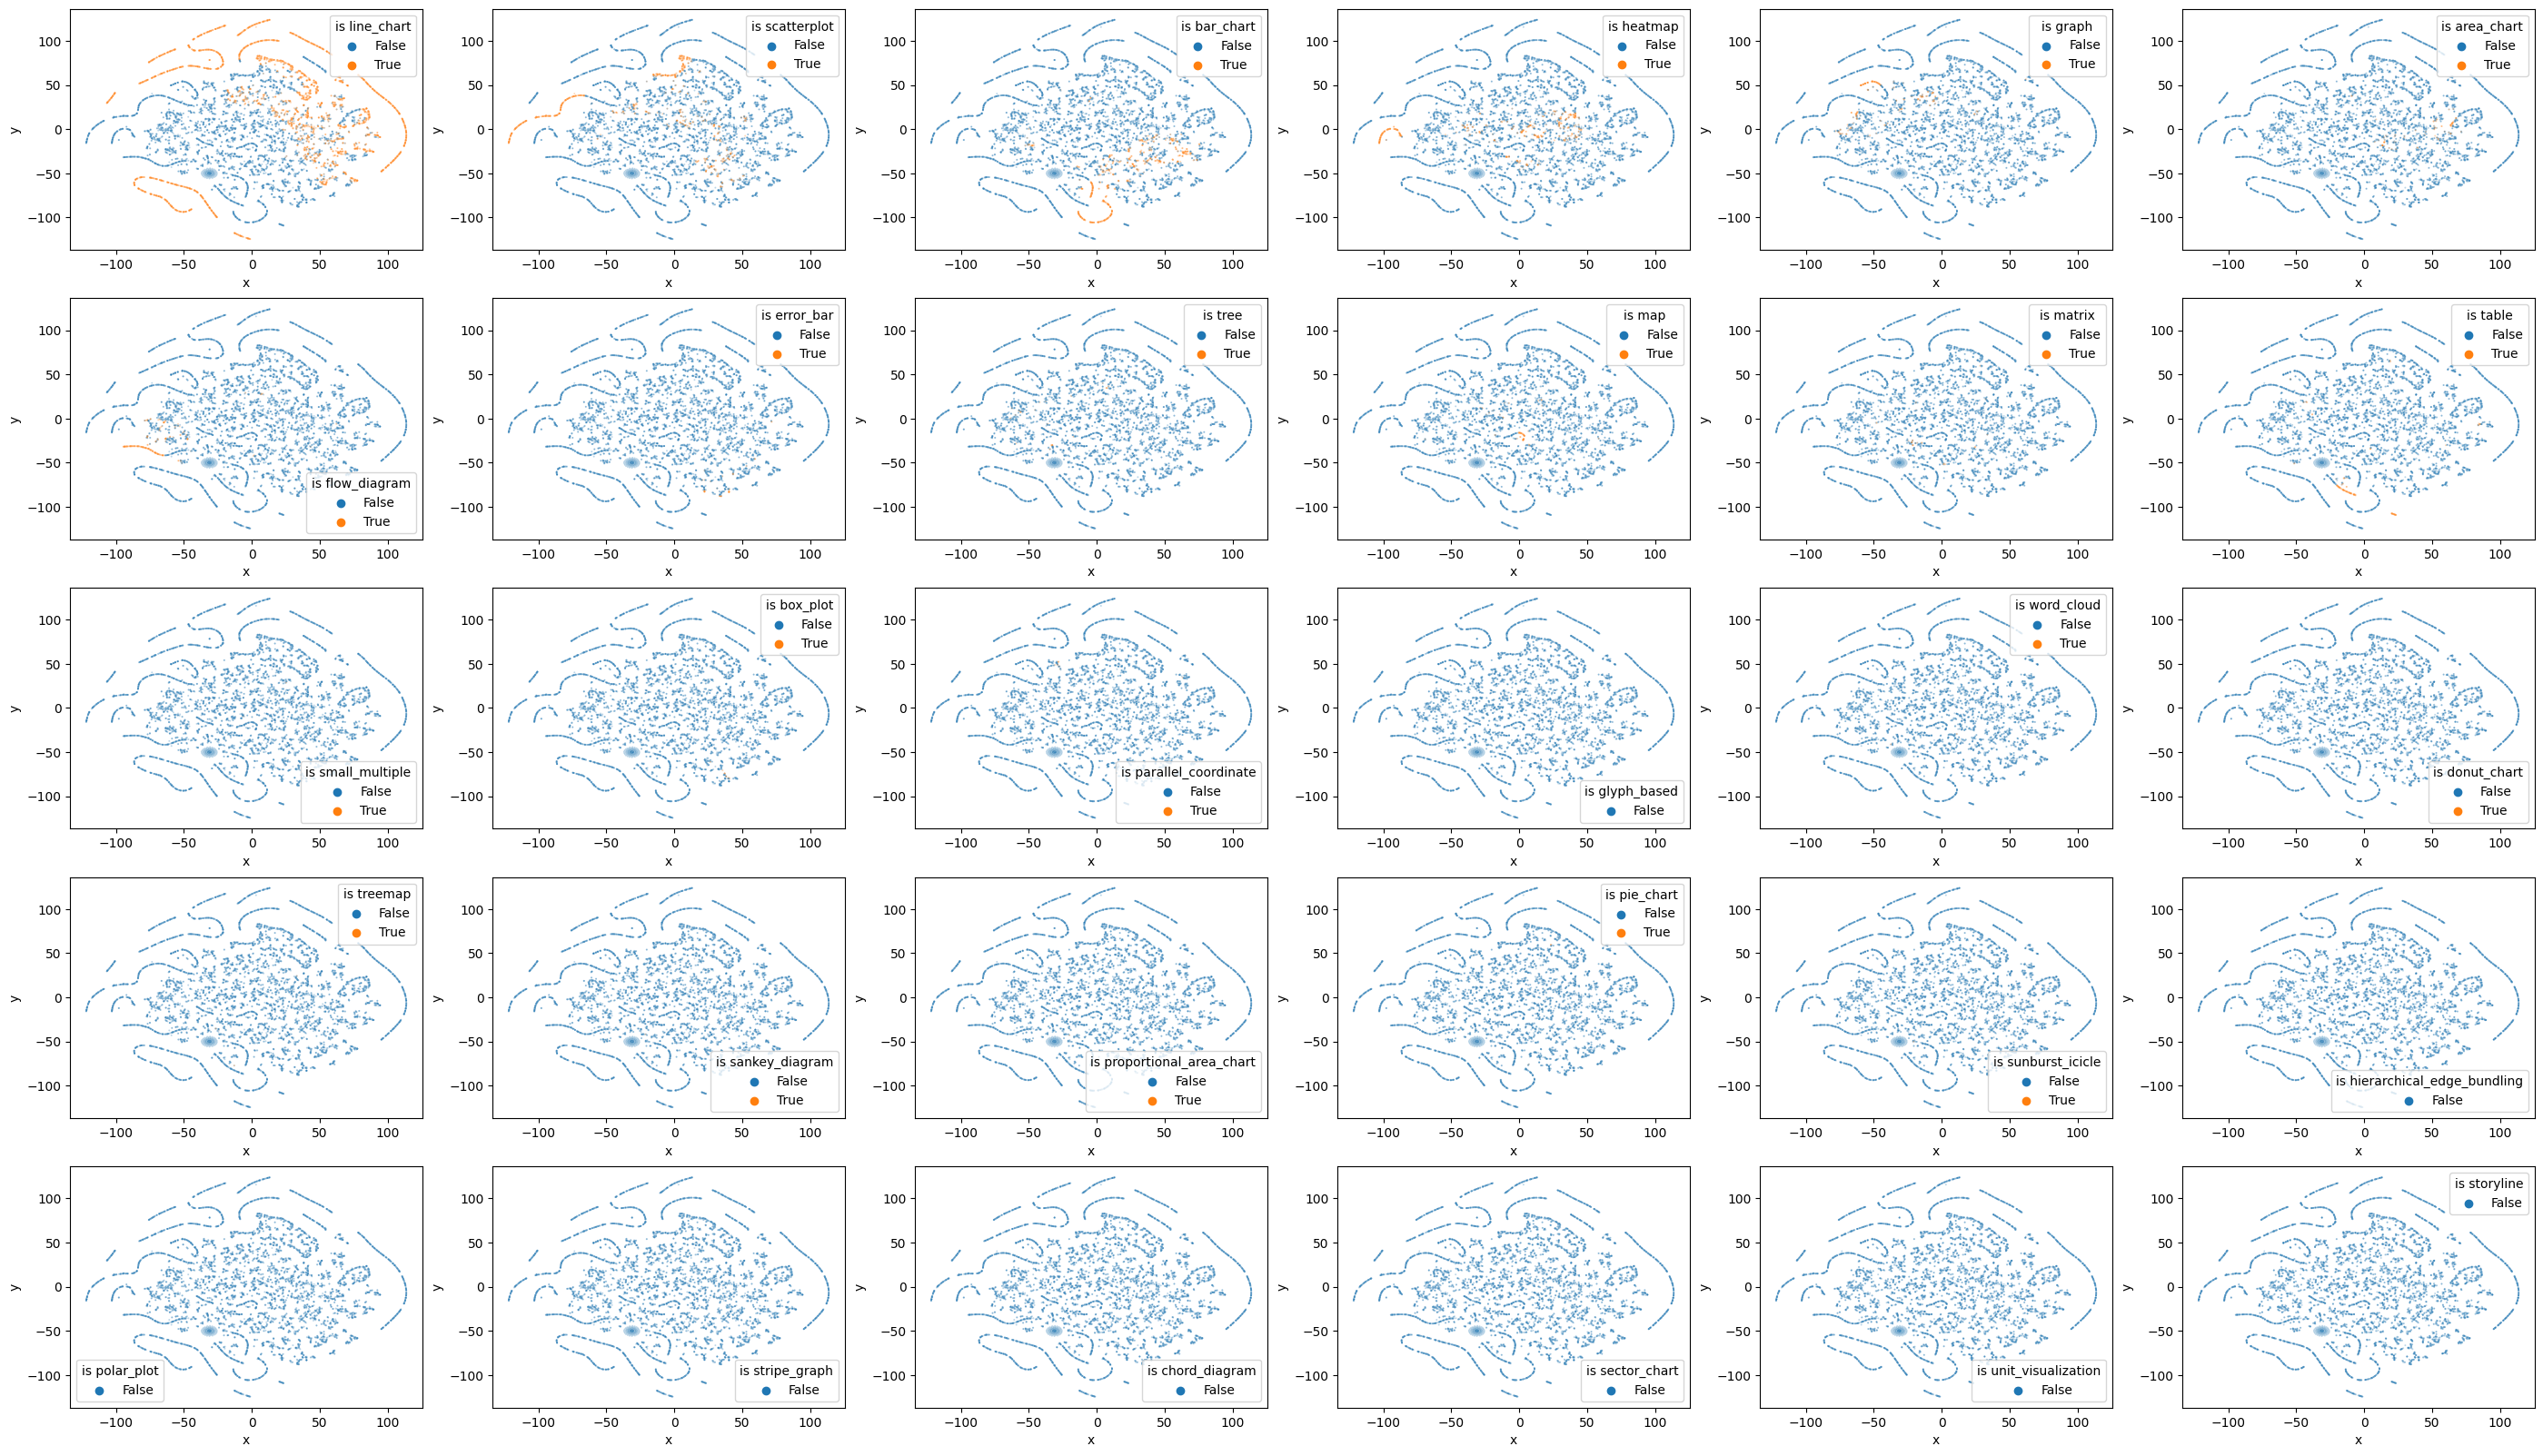

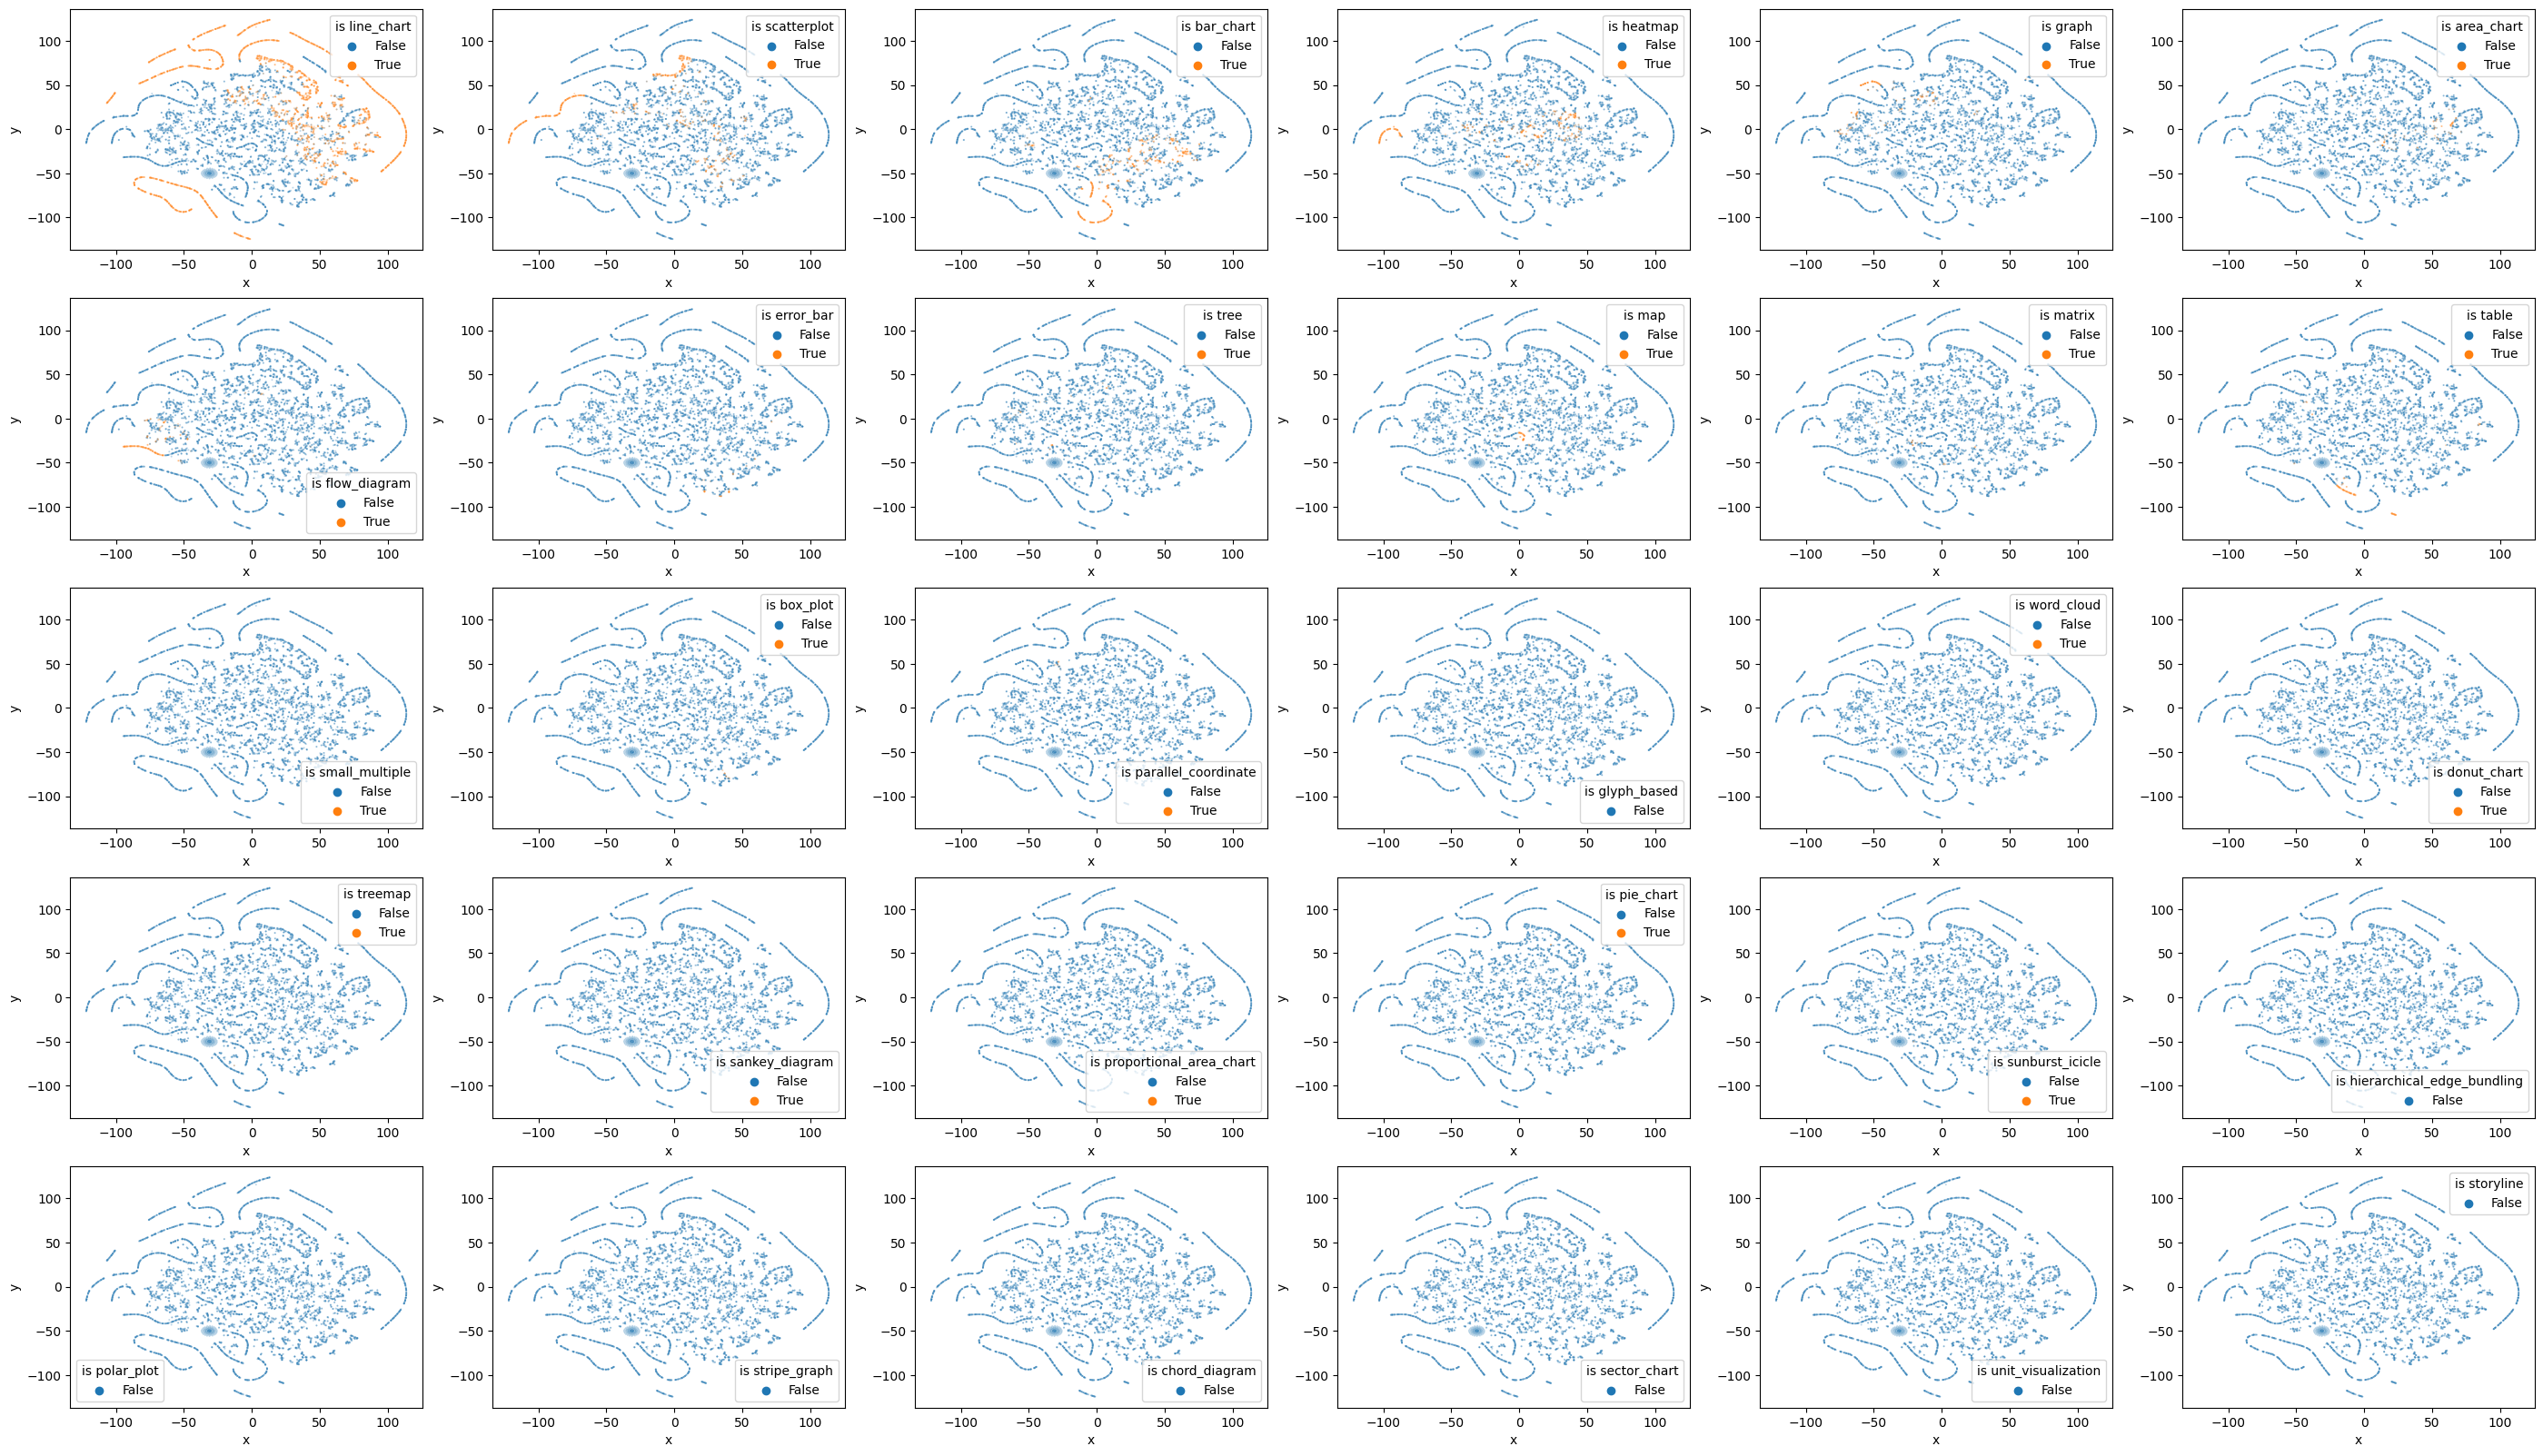

In [153]:
full_figure,axes = plt.subplots(5,6,figsize=(35,20))

# lets accentuate the bar chart locations
# order the columns by most entries positively scored
indices = (-1*df.sum()).argsort()
for i,ind in enumerate(indices):
    col=i%6
    row= i//6
    ax = axes[row,col]
    c = classes[ind]
    colors = df[c] > .9

    df_subset[f"is {c}"] = colors


    
    my_plot = sns.scatterplot(
        ax=ax,
        x="x", y="y", hue=f"is {c}",
        data=df_subset,
        s=2,
        legend="full",
        alpha=0.3
    )
#     my_plot.set(title=f"{c} neighborhood")
#     my_plot.get_figure().savefig(f"{c}_neighborhood.png")
full_figure

In [154]:
full_figure.get_figure().savefig("tiled.png")

In [ ]:
# using the db that zhiyang has already customized to work with the visualization code. we will just update the xyz positions


In [ ]:
pip install duckdb

In [ ]:
import duckdb as db

In [ ]:
connection = db.connect("original.db")

In [ ]:
connection.sql("SHOW TABLES")

In [ ]:
connection.sql("SELECT * FROM figure_property")

In [ ]:
connection.sql("DESCRIBE figure")

In [ ]:
paths = connection.sql("SELECT server_path FROM figure")

In [ ]:
from pathlib import Path

In [ ]:
figure_id_ordered_paths = [f"array_fig-{Path(pth).parent.name}-{Path(pth).stem}.json" for pth in paths.df().server_path]

In [ ]:
figure_id_ordered_paths[0]

In [ ]:
exists_check = [Path(f"outputs/{p}").exists() for p in figure_id_ordered_paths]

In [ ]:
# check to see how many figures in the table weren't chart typed
sum([not Path(f"outputs/{p}").exists() for p in figure_id_ordered_paths])

In [ ]:
# now create an array that maps from the order in the figure_id_ordered_paths to the indices of the original json arrays list which we built the arrays fr
lookup_map = {str(e.name):i for i,e in enumerate(arrays)}

In [ ]:
arrays[:5]

In [ ]:
exists_check[:5]

In [ ]:
# example for getting the index in our result array for the figure who's table id is 0
ex_figure_id_0 =figure_id_ordered_paths[0]
print(ex_figure_id_0)
array_index = lookup_map[ex_figure_id_0]
print(array_index)
# then we can use that same index to pull out the x,y,z coordinates that are supposed to replace the existing ones


In [ ]:
fig_prop_df = connection.sql("SELECT * FROM figure_property").df()

In [ ]:
fig_prop_df

In [ ]:

# this removes any of the missing figures so that we update just the correct ones
fig_prop_df[exists_check]

In [ ]:
# entirely possible that the updates are going to be easier as pandas instead of duckdb 

In [ ]:
# demonstration of reordering based on indexing

In [ ]:
rand_test = (np.random.random((15,3))*10).astype("uint8")

In [ ]:
rand_test

In [ ]:
inds = np.random.choice(np.arange(15),15,replace=False)

In [ ]:
inds

In [ ]:
rand_test[inds]

In [ ]:

# now create an array that maps from the order in the figure_id_ordered_paths to the indices of the original json arrays list which we built the arrays fr
lookup_map = {str(e.name):i for i,e in enumerate(arrays)}

arrays[:5]

exists_check[:5]

# example for getting the index in our result array for the figure who's table id is 0
ex_figure_id_0 =figure_id_ordered_paths[0]
print(ex_figure_id_0)
array_index = lookup_map[ex_figure_id_0]
print(array_index)

In [ ]:
array_indices = [lookup_map[fig_path] for i,fig_path in enumerate(figure_id_ordered_paths) if exists_check[i] ]
array_indices

In [ ]:
table_ordered_embeddings = embedding[array_indices]
table_ordered_embeddings.shape

In [ ]:
normalized_table = (table_ordered_embeddings - table_ordered_embeddings.min(axis=0))/(table_ordered_embeddings.max(axis=0) - table_ordered_embeddings.min(axis=0))

In [ ]:
normalized_table

In [ ]:
np.column_stack([normalized_table[:,0],np.zeros_like(normalized_table[:,0]),normalized_table[:,1]])


In [ ]:
embedding.shape

In [ ]:
fig_prop_df

In [ ]:
padded = np.column_stack([normalized_table[:,0],np.zeros_like(normalized_table[:,0]),normalized_table[:,1]])


In [ ]:
integer_coordinates = padded*2000 - 1000
integer_coordinates[:,1] =0
integer_coordinates

In [ ]:
fig_prop_df.loc[exists_check,["xPos","yPos","zPos"]] = integer_coordinates.astype("int16")


In [ ]:
fig_prop_df

In [ ]:
# remove the old outdated table, and the bring in the newer one

In [ ]:
connection = db.connect("original.db")

In [ ]:
#connection.close()

In [ ]:
!rm new.db

In [ ]:
new_con = db.connect("new.db")

for tbl in connection.sql("SHOW TABLES").df().name:
    if tbl == "charts" or tbl == "work_keyword" or tbl == "work_topic":
        continue
    print(tbl)
    new_con.sql(f"CREATE TABLE {tbl} AS SELECT * FROM read_csv('{tbl}.csv', AUTO_DETECT=TRUE);")

In [ ]:
connection = new_con

In [ ]:
connection.sql("DROP TABLE figure_property")

In [ ]:
connection.sql("SHOW TABLES")

In [ ]:
connection.sql("CREATE TABLE figure_property AS SELECT * FROM fig_prop_df")

In [ ]:
connection.close()

In [ ]:
connection.sql("CHECKPOINT")

In [ ]:
connection.close()

In [ ]:
# double check that the values updated correctly
connection = db.connect("publications_princeton.36608975.db")
connection.sql("SELECT * FROM figure_property").df()

In [ ]:
connection.sql("FORCE CHECKPOINT")

In [ ]:
pip install duckdb==1.0.0

In [ ]:
import duckdb as db

In [ ]:
con = db.connect("publications_princeton.36608975.db")

In [ ]:
con

In [ ]:
con.sql("SHOW TABLES")

In [ ]:
tables

In [ ]:
for t in tables.name:
    print(t)
    con.sql(f"COPY {t} to '{t}.csv';")

In [ ]:
con.close()